# FINAL REPORT: Credit Scoring — Give Me Some Credit
## Bài tập lớn môn MLE501 — Trí tuệ nhân tạo / Học máy

**Sinh viên**: QuangMinh  
**Khóa**: MSE35HN  
**Ngày**: 2026-03-11

---

## Mục lục
1. [Giới thiệu bài toán](#1)
2. [Tổng quan dữ liệu & EDA](#2)
3. [Preprocessing & Feature Engineering](#3)
4. [Model Building](#4)
5. [Model Evaluation](#5)
6. [Kết luận & Khuyến nghị](#6)

<a id="1"></a>
## 1. Giới thiệu bài toán

### 1.1 Bối cảnh
Trong lĩnh vực tài chính — ngân hàng, **Credit Scoring** (chấm điểm tín dụng) là quy trình đánh giá khả năng trả nợ của khách hàng. Mục tiêu là **phân loại khách hàng thành 2 nhóm**:
- **Good (0)**: Khách hàng trả nợ đúng hạn
- **Bad (1)**: Khách hàng có nợ quá hạn nghiêm trọng trong vòng 2 năm

### 1.2 Dataset
- **Nguồn**: Kaggle Competition — [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit)
- **Training set**: 150,000 mẫu (có nhãn)
- **Test set**: 101,503 mẫu (không có nhãn — dùng cho submission Kaggle)
- **Features**: 10 đặc trưng tài chính (thu nhập, tỷ lệ nợ, lịch sử trả chậm, tuổi, v.v.)
- **Target**: `SeriousDlqin2yrs` (0 = Good, 1 = Bad)

### 1.3 Thách thức chính
- **Dữ liệu mất cân bằng nghiêm trọng**: 93.32% Good vs 6.68% Bad (tỷ lệ 13.96:1)
- **Missing values**: MonthlyIncome (19.8%), NumberOfDependents (2.6%)
- **Outliers cực đoan**: DebtRatio max = 329,664; RevolvingUtilization max = 50,708

### 1.4 Mục tiêu dự án
Đánh giá và so sánh hiệu quả của **5 mô hình Machine Learning**:
1. Logistic Regression (baseline)
2. LinearSVC (Support Vector Machine)
3. Random Forest
4. XGBoost
5. LightGBM

**Metrics chính**: AUC-ROC, Recall, F1-Score (không dùng Accuracy vì dữ liệu mất cân bằng)

<a id="2"></a>
## 2. Tổng quan dữ liệu & EDA (Phase 1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

from datetime import datetime
print(f"Final Report generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Load raw data for overview
train_df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
print(f"\nDataset: {train_df.shape[0]:,} mẫu × {train_df.shape[1]} cột")
print(f"Target distribution:")
print(f"  Good (0): {(train_df['SeriousDlqin2yrs']==0).sum():,} ({(train_df['SeriousDlqin2yrs']==0).mean()*100:.2f}%)")
print(f"  Bad  (1): {(train_df['SeriousDlqin2yrs']==1).sum():,} ({(train_df['SeriousDlqin2yrs']==1).mean()*100:.2f}%)")
print(f"  Tỷ lệ mất cân bằng: {(train_df['SeriousDlqin2yrs']==0).sum() / (train_df['SeriousDlqin2yrs']==1).sum():.2f}:1")

Final Report generated at: 2026-03-11 18:40:09

Dataset: 150,000 mẫu × 11 cột
Target distribution:
  Good (0): 139,974 (93.32%)
  Bad  (1): 10,026 (6.68%)
  Tỷ lệ mất cân bằng: 13.96:1


### 2.1 Các phát hiện chính từ EDA

| Phát hiện | Chi tiết |
|-----------|----------|
| **Mất cân bằng lớp** | 93.32% Good vs 6.68% Bad (13.96:1) |
| **Missing values** | MonthlyIncome: 29,731 (19.8%), NumberOfDependents: 3,924 (2.6%) |
| **Outliers cực đoan** | DebtRatio max=329,664 (median=0.37), RevolvingUtilization max=50,708 |
| **Features phân biệt tốt** | RevolvingUtilization, NumberOfTimes90DaysLate, các biến trả chậm |
| **Phân phối lệch phải** | Hầu hết features có skewness > 1 |

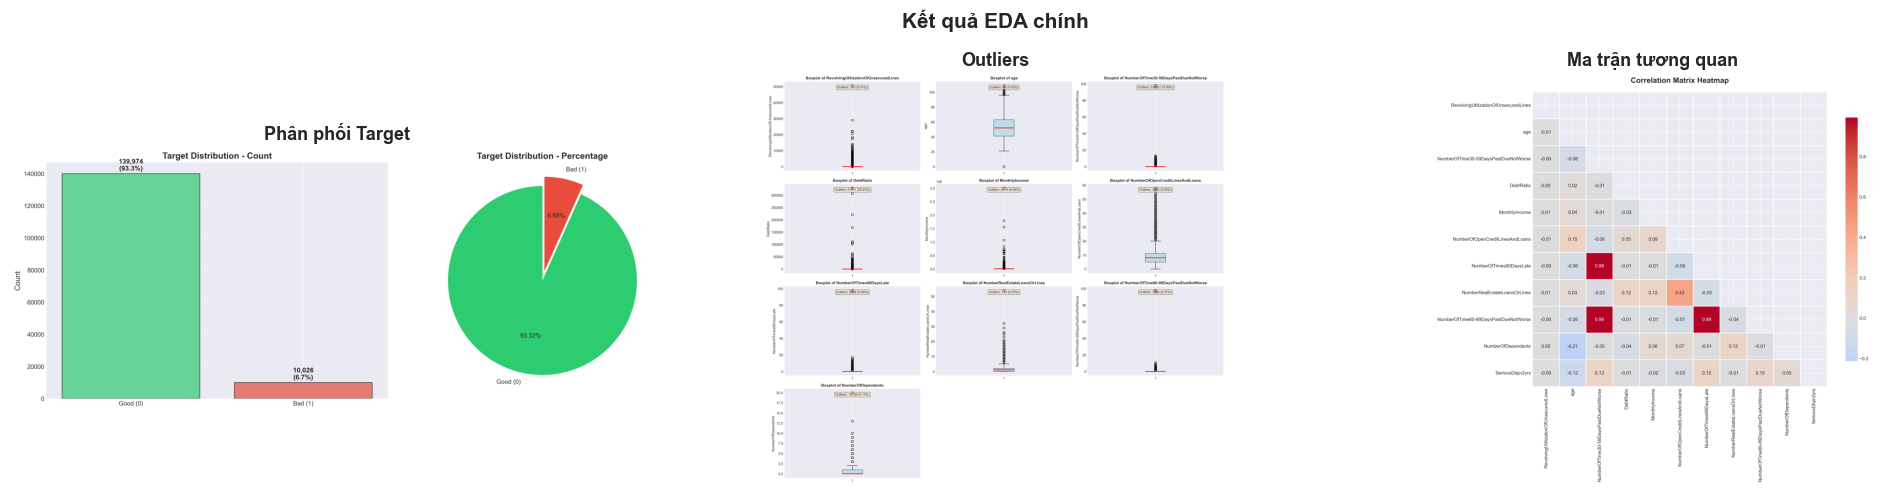

In [2]:
# Hiển thị kết quả EDA
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

eda_dir = '../reports/[1] Ket qua EDA/figures/'

for i, (fname, title) in enumerate([
    ('02_target_distribution.png', 'Phân phối Target'),
    ('04_boxplots_outliers.png', 'Outliers'),
    ('05_correlation_heatmap.png', 'Ma trận tương quan')
]):
    img = mpimg.imread(eda_dir + fname)
    axes[i].imshow(img)
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Kết quả EDA chính', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/[5] Final Report/eda_summary.png', dpi=200, bbox_inches='tight')
plt.show()

<a id="3"></a>
## 3. Preprocessing & Feature Engineering (Phase 2)

### 3.1 Pipeline xử lý

```
Raw Data (150,000 mẫu, 10 features)
    │
    ├─ [1] Handle Missing Values
    │      MonthlyIncome → median imputation (29,731 giá trị)
    │      NumberOfDependents → median imputation (3,924 giá trị)
    │
    ├─ [2] Handle Outliers (Capping)
    │      DebtRatio: max = 5 (từ 329,664)
    │      RevolvingUtilization: max = 2.0 (từ 50,708)
    │      Các biến trả chậm: max = 15
    │      age: 18 - 100
    │
    ├─ [3] Feature Engineering (+7 features mới)
    │      TotalLatePayments, HasLatePayment, IncomePerDependent,
    │      EstMonthlyDebt, HighDebt, AgeBin, HighCreditUtil
    │
    ├─ [4] Train-Validation Split (80/20, stratified)
    │      Training: ~120,000 | Validation: ~30,000
    │
    ├─ [5] SMOTE (1 lần, trên unscaled data)
    │      Tỷ lệ từ 13.96:1 → 2:1 (167,968 mẫu)
    │
    └─ [6] Feature Scaling (StandardScaler)
           Fit trên training → transform tất cả
```

In [3]:
# Data quality summary
quality = pd.read_csv('../reports/[2] Ket qua Preprocessing & Feature Engineering/data_quality_report.csv')
print("="*60)
print("DATA QUALITY REPORT SAU PREPROCESSING")
print("="*60)
display(quality)

DATA QUALITY REPORT SAU PREPROCESSING


,Metric,Value
0,Original Features,10
1,New Features (FE),7
2,Total Features,17
3,Total Samples (Training),"120,000"
4,Total Samples (After SMOTE),"167,968"
5,Total Samples (Validation),"30,000"
6,Total Samples (Test),"101,503"
7,Missing Values (Before),"33,655"
8,Missing Values (After),0
9,Outliers Capped,"30,841"


### 3.2 Feature Engineering — 7 features mới

| Feature | Công thức | Ý nghĩa |
|---------|-----------|---------|
| **TotalLatePayments** | Tổng 3 cột trả chậm | Tổng hợp tín hiệu nợ quá hạn |
| **HasLatePayment** | Binary: có trả chậm? | Đơn giản hóa tín hiệu |
| **IncomePerDependent** | Thu nhập / (Phụ thuộc + 1) | Năng lực tài chính theo đầu người |
| **EstMonthlyDebt** | DebtRatio × MonthlyIncome | Số nợ tuyệt đối hàng tháng |
| **HighDebt** | DebtRatio > 1 | Nợ vượt thu nhập |
| **AgeBin** | Nhóm tuổi (6 bin) | Hiệu ứng phi tuyến của tuổi |
| **HighCreditUtil** | Utilization > 100% | Sử dụng tín dụng quá mức |

### 3.3 Dữ liệu đầu ra

| Tập dữ liệu | Mục đích | Kích thước |
|-------------|----------|------------|
| X_train / X_train_scaled | Train model | ~120,000 × 17 |
| X_val / X_val_scaled | Đánh giá model | ~30,000 × 17 |
| X_train_smote / X_train_scaled_smote | Train với SMOTE | ~167,968 × 17 |
| X_test / X_test_scaled | Dự đoán (Kaggle) | 101,503 × 17 |

<a id="4"></a>
## 4. Model Building (Phase 3)

### 4.1 Cấu hình 5 models

| Model | Data | Xử lý imbalance | Params |
|-------|------|-----------------|--------|
| Logistic Regression | Scaled | class_weight='balanced' | Default (C=1.0) |
| LinearSVC | Scaled | class_weight='balanced' | Default (max_iter=2000) |
| Random Forest | Unscaled | class_weight='balanced' | Default (n_estimators=100) |
| XGBoost | Unscaled | scale_pos_weight=13.96 | Default (n_estimators=100) |
| LightGBM | Unscaled | is_unbalance=True | Default (n_estimators=100) |

**Ghi chú**: Tất cả models dùng default parameters, chưa tune hyperparameters.

In [4]:
# Load kết quả Phase 3
comparison = pd.read_csv('../reports/[3] Ket qua Model Building/model_comparison.csv')
print("="*60)
print("KẾT QUẢ TRAINING — 5 MODELS (Default Params)")
print("="*60)
print()
display(comparison.style.format({
    'AUC-ROC': '{:.4f}', 'Recall': '{:.4f}', 
    'F1-Score': '{:.4f}', 'Precision': '{:.4f}',
    'Train Time (s)': '{:.2f}'
}).highlight_max(subset=['AUC-ROC', 'Recall', 'F1-Score'], color='lightgreen'))

KẾT QUẢ TRAINING — 5 MODELS (Default Params)



,Model,AUC-ROC,Recall,F1-Score,Precision,Train Time (s)
0,LightGBM,0.8672,0.7711,0.3428,0.2204,0.26
1,Logistic Regression,0.8610,0.7616,0.3356,0.2152,1.57
2,LinearSVC,0.8574,0.0658,0.1182,0.5789,0.39
3,XGBoost,0.8506,0.7042,0.3534,0.2359,0.19
4,Random Forest,0.8335,0.1671,0.2566,0.5528,1.55


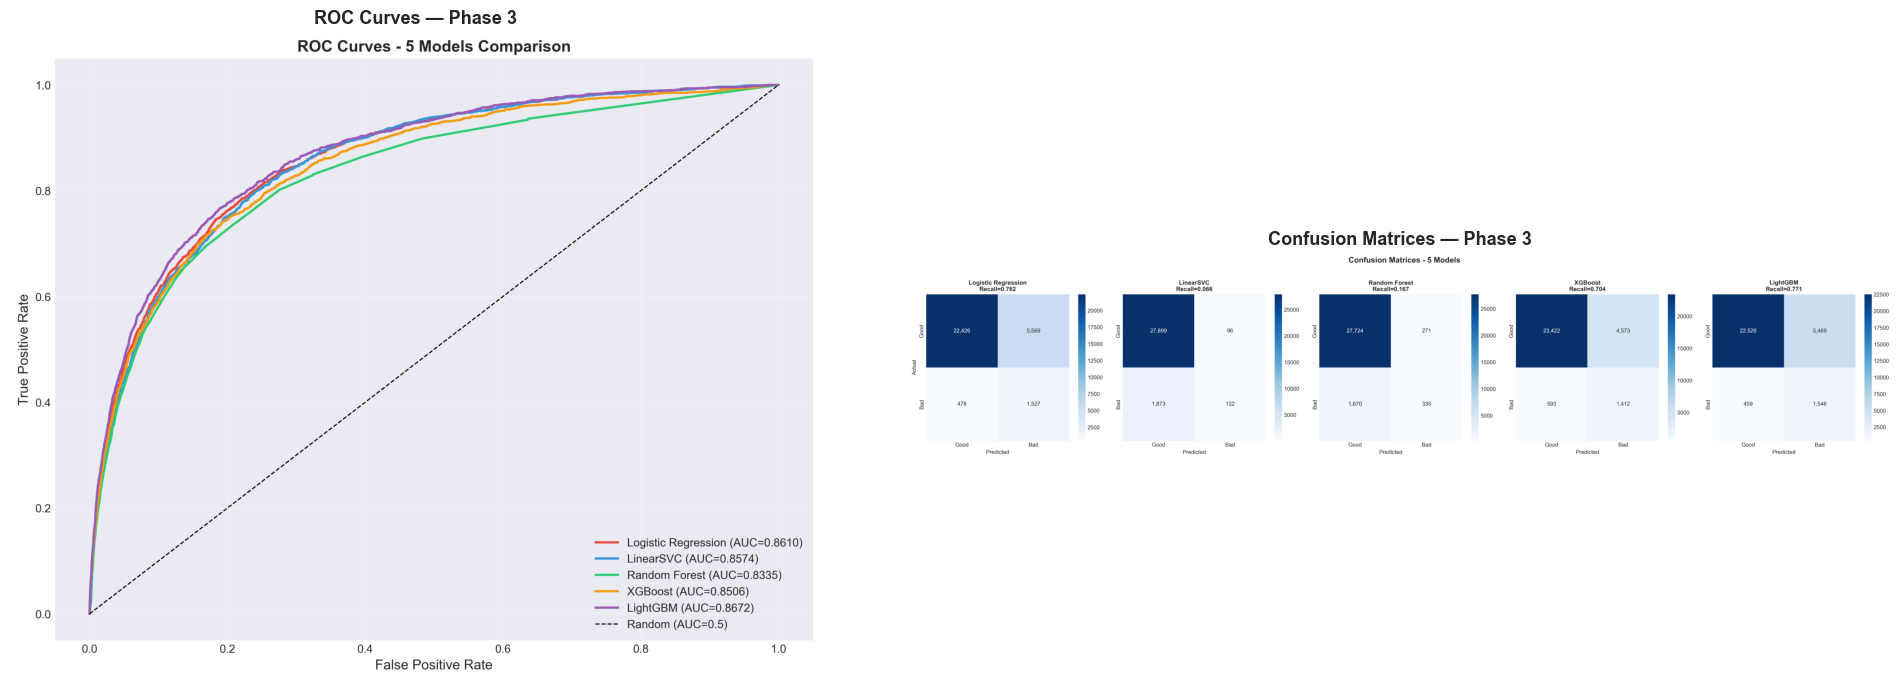

In [5]:
# Hiển thị ROC curves từ Phase 3
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

img1 = mpimg.imread('../reports/[3] Ket qua Model Building/roc_curves_comparison.png')
axes[0].imshow(img1)
axes[0].set_title('ROC Curves — Phase 3', fontsize=13, fontweight='bold')
axes[0].axis('off')

img2 = mpimg.imread('../reports/[3] Ket qua Model Building/confusion_matrices.png')
axes[1].imshow(img2)
axes[1].set_title('Confusion Matrices — Phase 3', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/[5] Final Report/model_building_summary.png', dpi=200, bbox_inches='tight')
plt.show()

### 4.2 Nhận xét Phase 3

1. **LightGBM** dẫn đầu: AUC-ROC = 0.8672, Recall = 0.7711
2. **Logistic Regression** bất ngờ tốt: AUC = 0.8610, Recall = 0.7616 — gần bằng LightGBM
3. **LinearSVC & Random Forest** kém: Recall chỉ 0.066 và 0.167 — bỏ sót >83% khách hàng xấu
4. Tất cả models có F1 thấp (0.11 - 0.35) — do dữ liệu mất cân bằng gây trade-off Recall/Precision

<a id="5"></a>
## 5. Model Evaluation (Phase 4)

In [6]:
# Load kết quả Phase 4
ranking = pd.read_csv('../reports/[4] Ket qua Model Evaluation/model_ranking.csv')
threshold = pd.read_csv('../reports/[4] Ket qua Model Evaluation/threshold_comparison.csv')

print("="*60)
print("BẢNG XẾP HẠNG TỔNG HỢP")
print("="*60)
print()
display(ranking[['Model', 'AUC-ROC', 'Recall', 'F1-Score', 'Precision', 'Avg_Rank']].style.format({
    'AUC-ROC': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 
    'Precision': '{:.4f}', 'Avg_Rank': '{:.1f}'
}).highlight_min(subset=['Avg_Rank'], color='lightgreen'))

BẢNG XẾP HẠNG TỔNG HỢP



,Model,AUC-ROC,Recall,F1-Score,Precision,Avg_Rank
0,LightGBM,0.8672,0.7711,0.3428,0.2204,2.0
1,XGBoost,0.8506,0.7042,0.3534,0.2359,2.8
2,Logistic Regression,0.8610,0.7616,0.3356,0.2152,3.0
3,LinearSVC,0.8574,0.0658,0.1182,0.5789,3.5
4,Random Forest,0.8335,0.1671,0.2566,0.5528,3.8


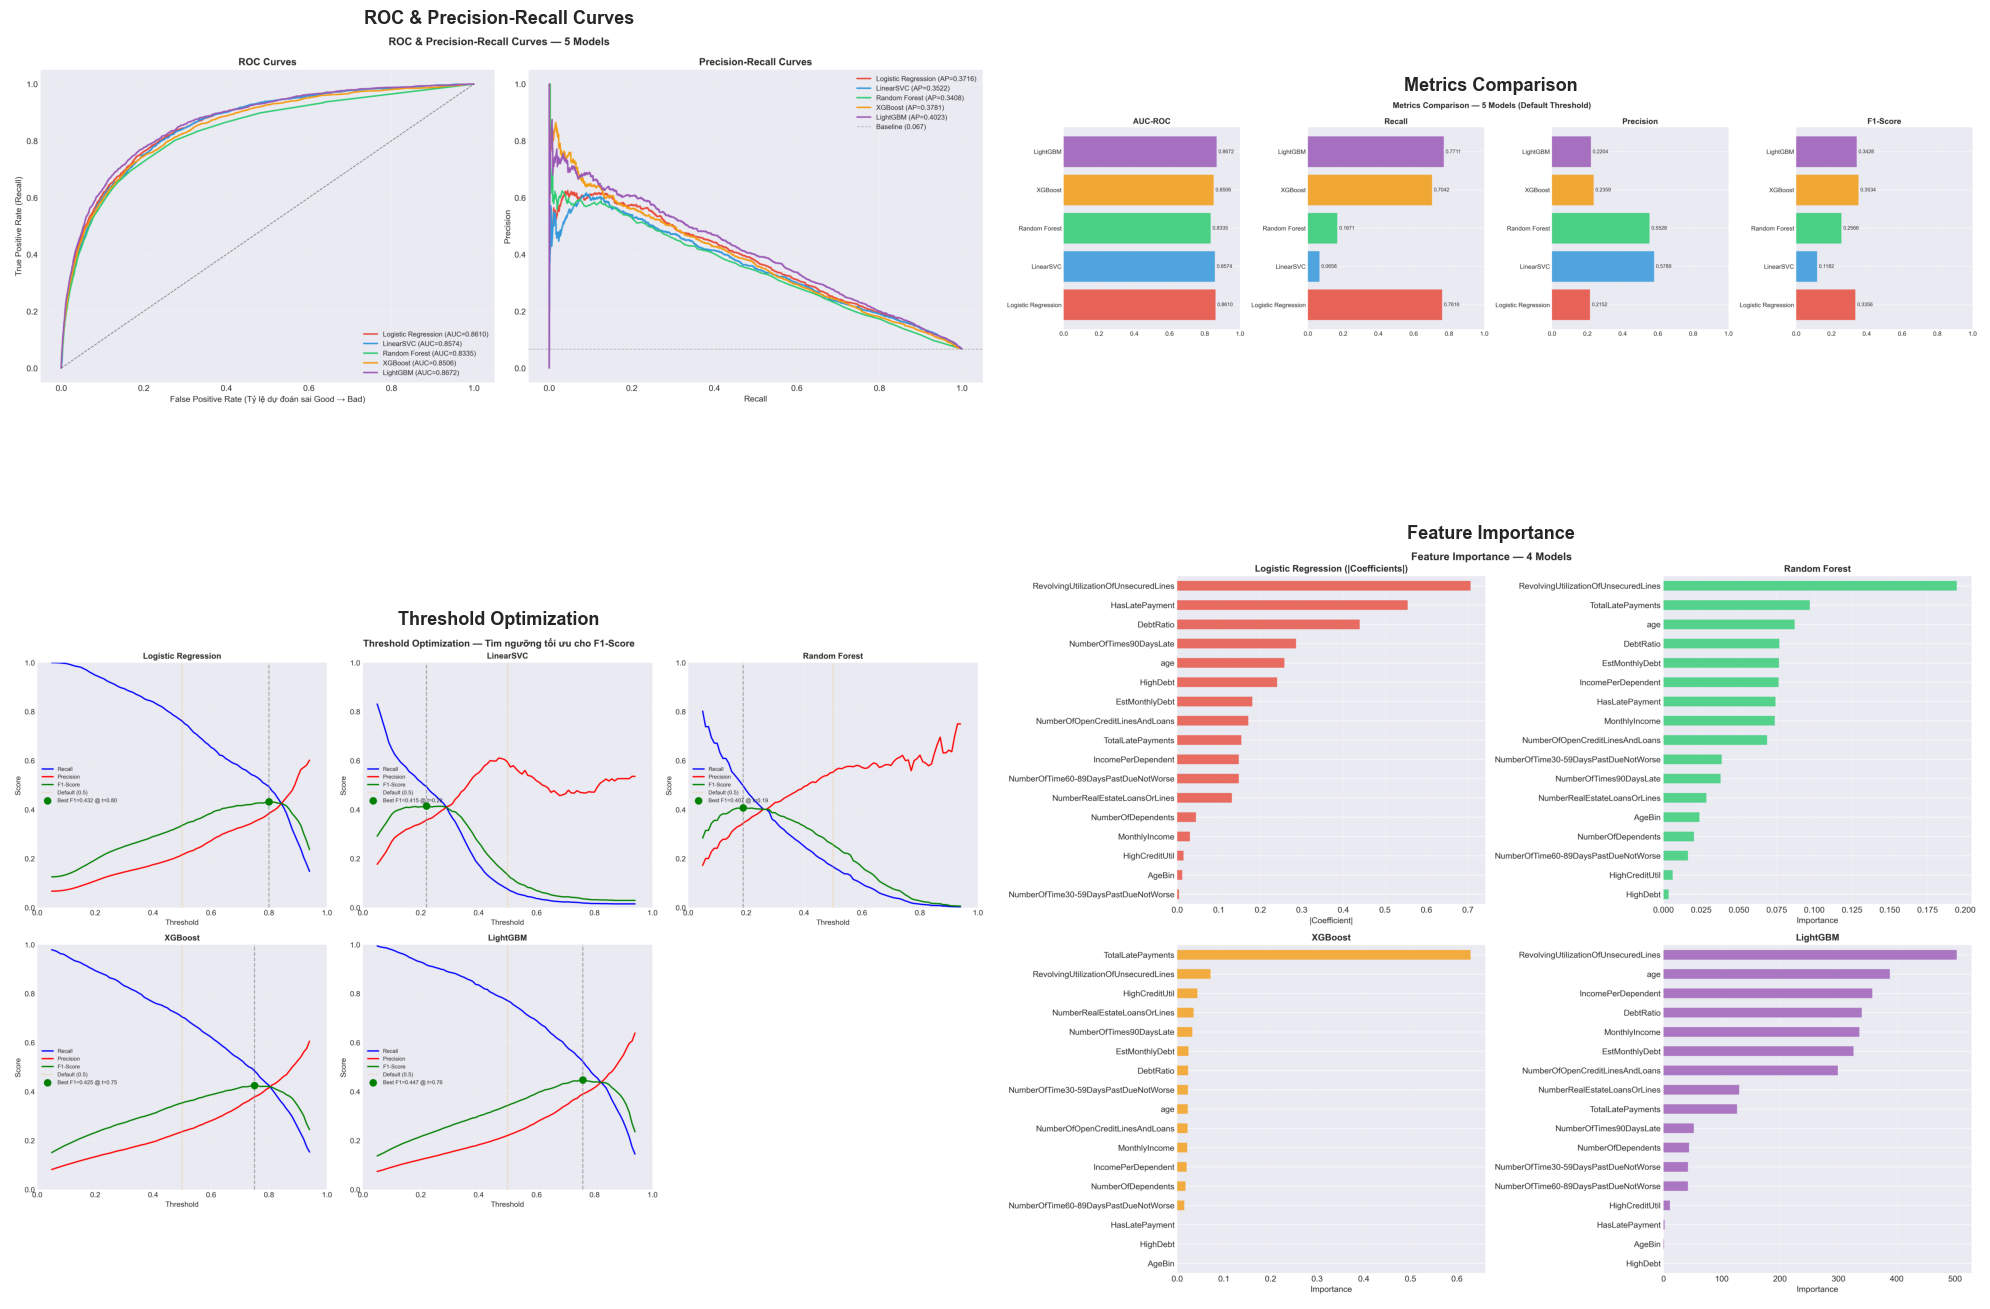

In [7]:
# Hiển thị các biểu đồ chính từ Phase 4
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

images = [
    ('../reports/[4] Ket qua Model Evaluation/roc_pr_curves.png', 'ROC & Precision-Recall Curves'),
    ('../reports/[4] Ket qua Model Evaluation/metrics_comparison_full.png', 'Metrics Comparison'),
    ('../reports/[4] Ket qua Model Evaluation/threshold_optimization.png', 'Threshold Optimization'),
    ('../reports/[4] Ket qua Model Evaluation/feature_importance_comparison.png', 'Feature Importance')
]

for i, (path, title) in enumerate(images):
    ax = axes[i // 2][i % 2]
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/[5] Final Report/evaluation_summary.png', dpi=200, bbox_inches='tight')
plt.show()

### 5.1 Threshold Optimization — Cải thiện đáng kể

In [8]:
print("="*60)
print("SO SÁNH: DEFAULT vs OPTIMIZED THRESHOLD")
print("="*60)
print()
display(threshold[['Model', 'Threshold', 'F1_default', 'F1_optimized', 'F1_change']].style.format({
    'F1_default': '{:.4f}', 'F1_optimized': '{:.4f}', 'F1_change': '{:+.4f}'
}))
print("\n→ Tất cả 5 models đều cải thiện F1 khi điều chỉnh threshold")
print("→ LinearSVC cải thiện nhiều nhất: +0.2963 (từ 0.1182 lên 0.4146)")

SO SÁNH: DEFAULT vs OPTIMIZED THRESHOLD



,Model,Threshold,F1_default,F1_optimized,F1_change
0,Logistic Regression,0.50 → 0.80,0.3356,0.4321,+0.0966
1,LinearSVC,0.50 → 0.22,0.1182,0.4146,+0.2963
2,Random Forest,0.50 → 0.19,0.2566,0.4054,+0.1488
3,XGBoost,0.50 → 0.75,0.3534,0.4248,+0.0714
4,LightGBM,0.50 → 0.76,0.3428,0.4471,+0.1044



→ Tất cả 5 models đều cải thiện F1 khi điều chỉnh threshold
→ LinearSVC cải thiện nhiều nhất: +0.2963 (từ 0.1182 lên 0.4146)


### 5.2 Error Analysis (LightGBM)

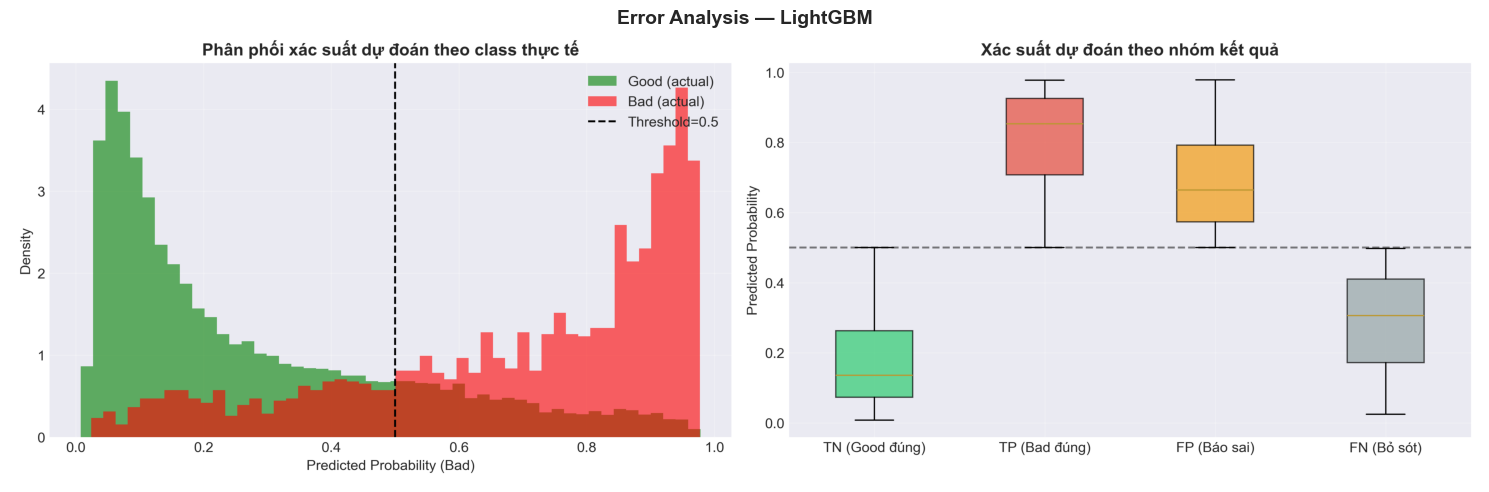

Nhận xét:
• Nhóm FN (Bad bị bỏ sót): xác suất dự đoán ~0.3 — đây là khách hàng Bad 'ẩn'
  có hành vi tương tự Good nhưng thực tế không trả được nợ
• Nhóm FP (Good bị báo sai): xác suất ~0.7 — profile rủi ro cao nhưng thực tế trả nợ tốt
• Vùng chồng lấn 0.2-0.6 là nơi model khó phân biệt nhất


In [9]:
# Error Analysis
img = mpimg.imread('../reports/[4] Ket qua Model Evaluation/error_analysis.png')
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.imshow(img)
ax.axis('off')
ax.set_title('Error Analysis — LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/[5] Final Report/error_analysis_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Nhận xét:")
print("• Nhóm FN (Bad bị bỏ sót): xác suất dự đoán ~0.3 — đây là khách hàng Bad 'ẩn'")
print("  có hành vi tương tự Good nhưng thực tế không trả được nợ")
print("• Nhóm FP (Good bị báo sai): xác suất ~0.7 — profile rủi ro cao nhưng thực tế trả nợ tốt")
print("• Vùng chồng lấn 0.2-0.6 là nơi model khó phân biệt nhất")

### 5.3 Feature Importance — Top features quan trọng nhất

| # | Feature | Vai trò | Đóng góp |
|---|---------|---------|----------|
| 1 | **RevolvingUtilizationOfUnsecuredLines** | Tỷ lệ sử dụng tín dụng | Top 1 ở LR, RF, LightGBM |
| 2 | **TotalLatePayments** *(FE mới)* | Tổng số lần trả chậm | Top 1 ở XGBoost |
| 3 | **age** | Tuổi khách hàng | Top 3 ở RF, XGBoost, LightGBM |
| 4 | **DebtRatio** | Tỷ lệ nợ/thu nhập | Top 5 ở cả 4 models |
| 5 | **NumberOfTimes90DaysLate** | Số lần trả chậm >90 ngày | Top 3 ở LR, XGBoost |

**Kết luận Feature Engineering**: TotalLatePayments (feature mới) trở thành feature quan trọng nhất ở XGBoost — chứng tỏ FE mang lại giá trị thực sự.

<a id="6"></a>
## 6. Kết luận & Khuyến nghị

In [10]:
print("="*80)
print("KẾT LUẬN TỔNG HỢP DỰ ÁN")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════╗
║                    XẾP HẠNG CUỐI CÙNG                       ║
╠══════╦═════════════════════════╦════════════╦════════════════╣
║ Hạng ║ Model                   ║ AUC-ROC    ║ Recall         ║
╠══════╬═════════════════════════╬════════════╬════════════════╣
║  1   ║ LightGBM               ║ 0.8672     ║ 0.7711         ║
║  2   ║ XGBoost                ║ 0.8506     ║ 0.7042         ║
║  3   ║ Logistic Regression    ║ 0.8610     ║ 0.7616         ║
║  4   ║ LinearSVC              ║ 0.8574     ║ 0.0658         ║
║  5   ║ Random Forest          ║ 0.8335     ║ 0.1671         ║
╚══════╩═════════════════════════╩════════════╩════════════════╝
""")

KẾT LUẬN TỔNG HỢP DỰ ÁN

╔══════════════════════════════════════════════════════════════╗
║                    XẾP HẠNG CUỐI CÙNG                       ║
╠══════╦═════════════════════════╦════════════╦════════════════╣
║ Hạng ║ Model                   ║ AUC-ROC    ║ Recall         ║
╠══════╬═════════════════════════╬════════════╬════════════════╣
║  1   ║ LightGBM               ║ 0.8672     ║ 0.7711         ║
║  2   ║ XGBoost                ║ 0.8506     ║ 0.7042         ║
║  3   ║ Logistic Regression    ║ 0.8610     ║ 0.7616         ║
║  4   ║ LinearSVC              ║ 0.8574     ║ 0.0658         ║
║  5   ║ Random Forest          ║ 0.8335     ║ 0.1671         ║
╚══════╩═════════════════════════╩════════════╩════════════════╝



### 6.1 Model tốt nhất: LightGBM

| Tiêu chí | Giá trị |
|----------|---------|
| AUC-ROC | **0.8672** (cao nhất) |
| Recall | **0.7711** (phát hiện 77% khách hàng xấu) |
| F1-Score (sau threshold optimization) | **0.4471** |
| Thời gian train | **0.26s** (nhanh nhất) |

### 6.2 Phân tích theo nhóm model

**Nhóm hiệu quả cao (LightGBM, XGBoost, Logistic Regression):**
- AUC-ROC > 0.85 và Recall > 0.70
- Xử lý imbalance bằng class_weight/scale_pos_weight hiệu quả
- Phù hợp cho bài toán Credit Scoring

**Nhóm hiệu quả thấp (LinearSVC, Random Forest):**
- Recall cực thấp với default threshold (< 0.17) — bỏ sót >83% khách hàng xấu
- Nguyên nhân: threshold = 0.5 không phù hợp với dữ liệu mất cân bằng
- Sau threshold optimization, F1 cải thiện đáng kể nhưng vẫn kém hơn nhóm trên

### 6.3 Các phát hiện quan trọng

1. **Threshold Optimization rất quan trọng** — cải thiện F1 của tất cả 5 models, đặc biệt LinearSVC (+0.2963)
2. **Feature Engineering mang lại giá trị** — TotalLatePayments trở thành feature quan trọng nhất ở XGBoost
3. **Logistic Regression đáng ngạc nhiên** — model đơn giản nhất nhưng cho kết quả gần bằng LightGBM về AUC-ROC
4. **Dữ liệu mất cân bằng là thách thức lớn nhất** — class_weight giúp LR, LightGBM, XGBoost nhưng chưa đủ cho LinearSVC và RF

### 6.4 Khuyến nghị

**Cho ứng dụng thực tế (ngân hàng):**
- Sử dụng **LightGBM** làm model chính
- Kết hợp **Threshold Optimization** để cân bằng giữa Recall (phát hiện khách xấu) và Precision (giảm từ chối nhầm khách tốt)
- Có thể dùng **Logistic Regression** song song — dễ giải thích hơn cho auditing

**Cho cải thiện tiếp theo:**
- Hyperparameter Tuning cho LightGBM và XGBoost (có thể cải thiện thêm 1-3%)
- Thử nghiệm SMOTE thay cho class_weight
- Thu thập thêm features (lịch sử giao dịch, thông tin nghề nghiệp, v.v.)

In [11]:
print("="*80)
print("KAGGLE SUBMISSION")
print("="*80)
print("\nFile submission đã được tạo bằng LightGBM (best model):")
print("  File: data/submission/submission_lightgbm.csv")
print("  Số mẫu dự đoán: 101,503")
print("  Format: Id, Probability")

# Verify file exists
sub_path = '../data/submission/submission_lightgbm.csv'
if os.path.exists(sub_path):
    sub = pd.read_csv(sub_path)
    print(f"\nPreview:")
    print(sub.head(10).to_string(index=False))
    print(f"\nThống kê xác suất Bad:")
    print(f"  Min: {sub['Probability'].min():.4f}")
    print(f"  Max: {sub['Probability'].max():.4f}")
    print(f"  Mean: {sub['Probability'].mean():.4f}")
    print(f"  Median: {sub['Probability'].median():.4f}")
else:
    print("\n⚠️ File chưa được tạo. Chạy predict_submission.py trước.")

KAGGLE SUBMISSION

File submission đã được tạo bằng LightGBM (best model):
  File: data/submission/submission_lightgbm.csv
  Số mẫu dự đoán: 101,503
  Format: Id, Probability

Preview:
 Id  Probability
  1     0.517196
  2     0.449248
  3     0.151001
  4     0.475663
  5     0.634875
  6     0.268329
  7     0.403738
  8     0.365003
  9     0.030906
 10     0.929714

Thống kê xác suất Bad:
  Min: 0.0076
  Max: 0.9789
  Mean: 0.3049
  Median: 0.2027


In [12]:
print("\n" + "="*80)
print("═" * 80)
print("   DỰ ÁN HOÀN THÀNH — Give Me Some Credit — Credit Scoring")
print("═" * 80)
print(f"\n  Thời gian: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n  Phases đã thực hiện:")
print("    ✅ Phase 1: EDA")
print("    ✅ Phase 2: Preprocessing & Feature Engineering")
print("    ✅ Phase 3: Model Building")
print("    ✅ Phase 4: Model Evaluation")
print("    ✅ Phase 5: Final Report")
print("\n  Best Model: LightGBM (AUC-ROC = 0.8672)")
print("  Kaggle Submission: data/submission/submission_lightgbm.csv")
print("\n" + "═" * 80)


════════════════════════════════════════════════════════════════════════════════
   DỰ ÁN HOÀN THÀNH — Give Me Some Credit — Credit Scoring
════════════════════════════════════════════════════════════════════════════════

  Thời gian: 2026-03-11 18:40:20

  Phases đã thực hiện:
    ✅ Phase 1: EDA
    ✅ Phase 2: Preprocessing & Feature Engineering
    ✅ Phase 3: Model Building
    ✅ Phase 4: Model Evaluation
    ✅ Phase 5: Final Report

  Best Model: LightGBM (AUC-ROC = 0.8672)
  Kaggle Submission: data/submission/submission_lightgbm.csv

════════════════════════════════════════════════════════════════════════════════
